In [35]:
%pip install langgraph
%pip install Ipython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [37]:
#define state
class BMIstate(TypedDict):
    weight_kg:float
    height_m:float
    bmi :float
    category:str

In [38]:
def calculate_bmi_fun(state:BMIstate)->BMIstate:
    weight=state['weight_kg']
    height=state['height_m']

    bmi=weight/(height**2)
    state['bmi']=round(bmi,2)
    return state

    

In [39]:
def label_bmi(state:BMIstate)->BMIstate:
    bmi=state['bmi']
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state
    

In [43]:
#Define your graph
graph=StateGraph(BMIstate)
#add notes to your graph
graph.add_node('calculator_bmi',calculate_bmi_fun)
graph.add_node('label_bmi',label_bmi)
#add edges to your graph
graph.add_edge(START,'calculator_bmi')
graph.add_edge('calculator_bmi','label_bmi')
graph.add_edge('label_bmi',END)
#Compile  the graphllll
workflow=graph.compile()

In [44]:
#excute the graph
intial_state={'weight_kg':80,'height_m':1.73}
final_state=workflow.invoke(intial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


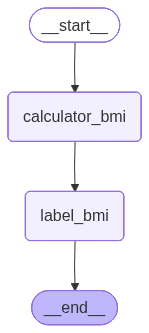

In [45]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))
